# Titanic Survival Prediction

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

### Data_Overview

In [2]:
df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.shape

(891, 12)

In [5]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [6]:
df.nunique()

PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             88
SibSp            7
Parch            7
Ticket         681
Fare           248
Cabin          147
Embarked         3
dtype: int64

In [7]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [8]:
# extraacting new features before dropping name
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

df['Title'] = df['Title'].replace(
    ['Lady','Countess','Capt','Col','Don','Dr','Major','Rev','Sir','Jonkheer','Dona'],
    'Rare'
)
df['Title'] = df['Title'].replace(['Mlle','Ms'], 'Miss')
df['Title'] = df['Title'].replace('Mme', 'Mrs')

In [9]:
DROP_COLS = ['Survived', 'PassengerId', 'Name', 'Ticket', 'Cabin']
X = df.drop(DROP_COLS, axis=1)
y = df['Survived']

In [10]:
X.dtypes

Pclass          int64
Sex            object
Age           float64
SibSp           int64
Parch           int64
Fare          float64
Embarked       object
FamilySize      int64
IsAlone         int64
Title          object
dtype: object

In [11]:
X.nunique()

Pclass          3
Sex             2
Age            88
SibSp           7
Parch           7
Fare          248
Embarked        3
FamilySize      9
IsAlone         2
Title           5
dtype: int64

### Balancing Checks

In [12]:
y.value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

### Splitting Data 

In [13]:
#slight imbalance, we should stratify
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.22, random_state=42, stratify=y)

In [14]:
numerical_features = X_train.select_dtypes(include=['number']).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

In [15]:
((numerical_features),(categorical_features))

(['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone'],
 ['Sex', 'Embarked', 'Title'])

### Preprocessing_Pipelines

In [16]:
numerical_transformer=Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='median')),
    ('scaler',StandardScaler())
])
categorical_transformer=Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [17]:
preprocessor=ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

### Model

In [18]:
rf_param_grid = {
    'classifier__n_estimators': [30, 50, 100 , 125],
    'classifier__max_depth': [None, 10, 20, 30],
    'classifier__min_samples_split': [2, 5]
}

In [19]:
cv = StratifiedKFold(n_splits=5, shuffle=True)

In [20]:
y_train = y_train.squeeze()

In [21]:
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

rf_grid = GridSearchCV(
    rf_pipeline,
    rf_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

rf_grid.fit(X_train, y_train)

Fitting 5 folds for each of 32 candidates, totalling 160 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'classifier__max_depth': [None, 10, ...], 'classifier__min_samples_split': [2, 5], 'classifier__n_estimators': [30, 50, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [22]:
rf = rf_grid.best_estimator_

In [23]:
y_pred_rf = rf_grid.predict(X_test)
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.82      0.88      0.85       121
           1       0.78      0.70      0.74        76

    accuracy                           0.81       197
   macro avg       0.80      0.79      0.79       197
weighted avg       0.81      0.81      0.80       197



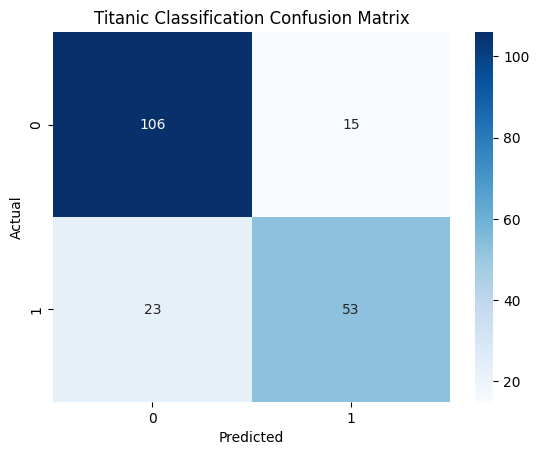

In [25]:
conf_matrix = confusion_matrix(y_test, y_pred_rf)
plt.figure()
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='d')
plt.title('Titanic Classification Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [26]:
experiment_log = {
    "model": "RandomForestClassifier",
    "cv_score_mean": rf_grid.best_score_,
    "best_params": rf_grid.best_params_,
}

from pprint import pprint
pprint(experiment_log)

{'best_params': {'classifier__max_depth': 20,
                 'classifier__min_samples_split': 5,
                 'classifier__n_estimators': 30},
 'cv_score_mean': np.float64(0.835741841309561),
 'model': 'RandomForestClassifier'}


In [27]:
rf['preprocessor'].named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features)

array(['Sex_female', 'Sex_male', 'Embarked_C', 'Embarked_Q', 'Embarked_S',
       'Title_Master', 'Title_Miss', 'Title_Mr', 'Title_Mrs',
       'Title_Rare'], dtype=object)

In [28]:
feature_importances = rf['classifier'].feature_importances_

feature_names = numerical_features + list(rf['preprocessor']
                                        .named_transformers_['cat']
                                        .named_steps['onehot']
                                        .get_feature_names_out(categorical_features))

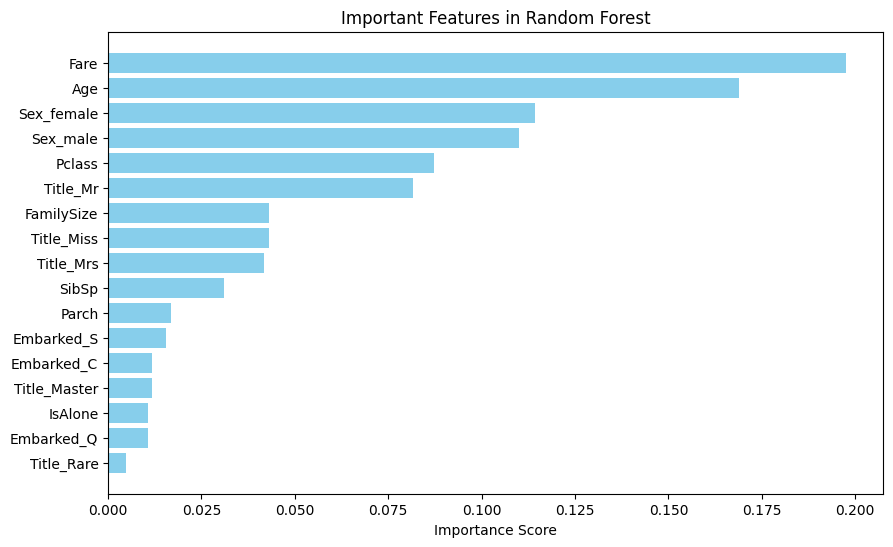


Test set accuracy: 80.71%


In [29]:
importance_df = pd.DataFrame({'Feature': feature_names,
                              'Importance': feature_importances
                             }).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.gca().invert_yaxis() 
plt.title('Important Features in Random Forest')
plt.xlabel('Importance Score')
plt.show()

test_score = rf.score(X_test, y_test)
print(f"\nTest set accuracy: {test_score:.2%}")

It's crucially important to realize that there is most likely plenty of dependence amongst these variables, and a more detailed modelling approach including correlation analysis is required to draw proper conclusions.

### Try other models


In [30]:
lr_param_grid = {
    'classifier__C': [0.05, 0.1, 0.5, 1, 5],
    'classifier__penalty': ['l1', 'l2'],
    'classifier__solver': ['liblinear']
}

In [31]:
cv = StratifiedKFold(n_splits=5, shuffle=True)

In [32]:
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42))
])

lr_grid = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=lr_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

lr_grid.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'classifier__C': [0.05, 0.1, ...], 'classifier__penalty': ['l1', 'l2'], 'classifier__solver': ['liblinear']}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [33]:
lr = lr_grid.best_estimator_
y_pred_lr = lr.predict(X_test)

In [34]:
print(classification_report(y_test,y_pred_lr))

              precision    recall  f1-score   support

           0       0.84      0.87      0.85       121
           1       0.78      0.74      0.76        76

    accuracy                           0.82       197
   macro avg       0.81      0.80      0.81       197
weighted avg       0.82      0.82      0.82       197



In [35]:
experiment_log = {
    "model": "LogisticRegression",
    "cv_score_mean": lr_grid.best_score_,
    "best_params": lr_grid.best_params_,
}

from pprint import pprint
pprint(experiment_log)

{'best_params': {'classifier__C': 0.5,
                 'classifier__penalty': 'l2',
                 'classifier__solver': 'liblinear'},
 'cv_score_mean': np.float64(0.8242101970597435),
 'model': 'LogisticRegression'}


All of the scores are slightly better for logistic regression than for random forest classification, although the differences are insignificant

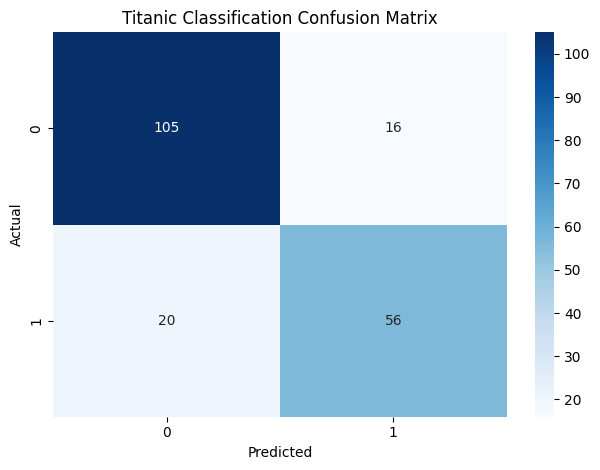

In [36]:
conf_matrix = confusion_matrix(y_test, y_pred_lr)

plt.figure()
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='d')

plt.title('Titanic Classification Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.show()

In [37]:
coefficients = lr.named_steps['classifier'].coef_[0]

numerical_feature_names = numerical_features
categorical_feature_names = (lr.named_steps['preprocessor']
                                     .named_transformers_['cat']
                                     .named_steps['onehot']
                                     .get_feature_names_out(categorical_features)
                            )
feature_names = numerical_feature_names + list(categorical_feature_names)

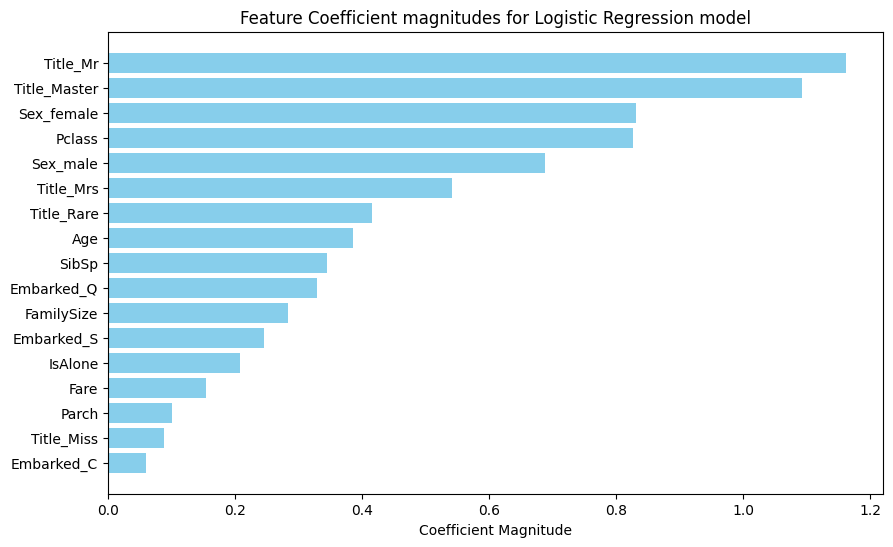


Test set accuracy: 81.73%


In [38]:
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
}).sort_values(by='Coefficient', ascending=False, key=abs)  # Sort by absolute values

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Coefficient'].abs(), color='skyblue')
plt.gca().invert_yaxis()
plt.title('Feature Coefficient magnitudes for Logistic Regression model')
plt.xlabel('Coefficient Magnitude')
plt.show()

test_score = lr.score(X_test, y_test)
print(f"\nTest set accuracy: {test_score:.2%}")

Although the performances of the two models are virtually identical, the features that are important to the two models are very different. 

### Prediction for test.csv

Best_model = lr

In [39]:
test_df['FamilySize'] = test_df['SibSp'] + df['Parch'] + 1
test_df['IsAlone'] = (test_df['FamilySize'] == 1).astype(int)

test_df['Title'] = test_df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
test_df['Title'] = test_df['Title'].replace(
    ['Lady','Countess','Capt','Col','Don','Dr','Major','Rev','Sir','Jonkheer','Dona'],
    'Rare'
)
test_df['Title'] = test_df['Title'].replace(['Mlle','Ms'], 'Miss')
test_df['Title'] = test_df['Title'].replace('Mme', 'Mrs')

In [40]:
test_ids = test_df['PassengerId']
test_preds = lr.predict(test_df)

submission = pd.DataFrame({
    'PassengerId': test_ids,
    'Survived': test_preds
})

submission.to_csv('submission2.csv', index=False)